# LangGraph

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* https://docs.langchain.com/oss/python/langgraph/quickstart
* https://docs.langchain.com/oss/python/langgraph/workflows-agents
* https://docs.langchain.com/oss/python/langgraph/persistence

## Задачи для совместного разбора

1\. Обсудите роль пакета `langgraph` в экосистеме `langchain`, основные возможностью по созданию графа состояний при помощи этого пакета.

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import langgraph

In [ ]:
class State(TypedDict):
  day: str
  message: str | None

In [ ]:
def generate_message(state: State):
  # ...
  message = "message from state: {}".format(state["day"])
  return {"message": message}

graph = StateGraph(State)

graph.add_node("build_message", generate_message)
# graph.add_node(...)

graph.add_edge(START, "build_message")
# graph.add_edge(...)
graph.add_edge("build_message", END)

app = graph.compile()
app.invoke({"day": "monday"})


{'day': 'monday', 'message': 'message from state: monday'}

In [ ]:
class State(TypedDict):
  text: str
  message_en: str | None
  message_ch: str | None

def generate_message_en(state: State):
  # ...
  message = "english message from text: {}".format(state["text"])
  return {"message_en": message}

def generate_message_ch(state: State):
  # ...
  message = "chinese message from text: {}".format(state["text"])
  return {"message_ch": message}

graph = StateGraph(State)

graph.add_node("build_message_en", generate_message_en)
graph.add_node("build_message_ch", generate_message_ch)

graph.add_edge(START, "build_message_en")
graph.add_edge(START, "build_message_ch")

graph.add_edge("build_message_en", END)
graph.add_edge("build_message_ch", END)

app = graph.compile()
app.invoke({"text": "пример текста"})


{'text': 'пример текста',
 'message_en': 'english message from text: пример текста',
 'message_ch': 'chinese message from text: пример текста'}

In [ ]:
import random

class State(TypedDict):
  text: str
  message_en: str | None
  message_ch: str | None

def generate_message_en(state: State):
  # ...
  message = "english message from text: {}".format(state["text"])
  return {"message_en": message}

def generate_message_ch(state: State):
  # ...
  message = "chinese message from text: {}".format(state["text"])
  return {"message_ch": message}

def condition(state: State):
  if random.random() <= 0.5:
    return "chinese"
  return "english"


graph = StateGraph(State)

graph.add_node("build_message_en", generate_message_en)
graph.add_node("build_message_ch", generate_message_ch)

graph.add_conditional_edges(
    START,
    condition,
    {
        "chinese": "build_message_ch",
        "english": "build_message_en"
    }
)

graph.add_edge("build_message_en", END)
graph.add_edge("build_message_ch", END)

app = graph.compile()
app.invoke({"text": "пример текста"})


{'text': 'пример текста',
 'message_en': 'english message from text: пример текста'}

In [ ]:
app.invoke({"text": "пример текста"})

{'text': 'пример текста',
 'message_ch': 'chinese message from text: пример текста'}

## Задачи для самостоятельного решения

In [13]:
import os
import random
from typing import TypedDict, Literal, Dict, Any, List
from pydantic import BaseModel, Field

from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.documents import Document

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display, Markdown

from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_BASE_URL"] = "https://api.proxyapi.ru/openai/v1"

<p class="task" id="1"></p>

1\. Создайте граф с простой последовательностью, который генерирует анекдот на заданную тему.
Для этого создайте 3 узла и последовательно свяжите их:
- узел setup_prompt: формирует сообщение для модели на основе входной темы (topic).
- узел call_model: отправляет сформированный промпт в LLM и получает ответ.
- узел uppercase_parser: забирает сгенерированный текст из ответа моели и переводит его ВЕРХНИЙ РЕГИСТР.
Визуализируйте полученный граф.

Выведите на экран результат работы для нескольких тем.

- [x] Проверено на семинаре

In [2]:
class JokeState(TypedDict):
    topic: str
    prompt: str
    response: str
    result: str

In [7]:
def setup_prompt(state: JokeState):
    prompt = f"Расскажи короткий и смешной анекдот на тему: {state['topic']}"
    return {"prompt": prompt}

def call_model(state: JokeState):
    llm = ChatOpenAI(
        model="gpt-5.4-mini", 
        temperature=0.7
        )
    response = llm.invoke(state["prompt"])
    return {"response": response.content}

def uppercase_parser(state: JokeState):
    return {"result": state["response"].upper()}

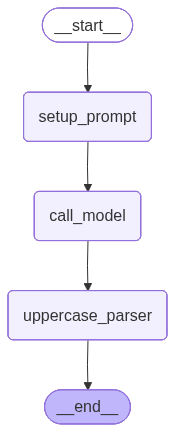

In [8]:
builder_joke = StateGraph(JokeState)

builder_joke.add_node("setup_prompt", setup_prompt)
builder_joke.add_node("call_model", call_model)
builder_joke.add_node("uppercase_parser", uppercase_parser)

builder_joke.add_edge(START, "setup_prompt")
builder_joke.add_edge("setup_prompt", "call_model")
builder_joke.add_edge("call_model", "uppercase_parser")
builder_joke.add_edge("uppercase_parser", END)

graph_joke = builder_joke.compile()

display(Image(graph_joke.get_graph().draw_mermaid_png()))


In [9]:
topics = ["искусственный интеллект", "базы данных", "Слоник PostgreSQL"]
for topic in topics:
    print(f"\nТема: {topic}")
    out = graph_joke.invoke({"topic": topic})
    print(out["result"])


Тема: искусственный интеллект
ИСКУССТВЕННЫЙ ИНТЕЛЛЕКТ СПРОСИЛИ:  
— ТЫ МОЖЕШЬ ЗАМЕНИТЬ ЧЕЛОВЕКА?  

ОН ПОДУМАЛ И ОТВЕТИЛ:  
— ДА. НО КТО ТОГДА БУДЕТ ОБЪЯСНЯТЬ МНЕ, КАК РАБОТАЕТ ПРИНТЕР?

Тема: базы данных
БАЗА ДАННЫХ ПРИШЛА К ПСИХОЛОГУ И ГОВОРИТ:

— У МЕНЯ ПРОБЛЕМЫ С ПАМЯТЬЮ.  
— А ДАВНО ЭТО НАЧАЛОСЬ?  
— **SELECT НЕ ПОМНЮ.**

Тема: Слоник PostgreSQL
СЛОНИК POSTGRESQL ПРИШЁЛ В ЗООПАРК И ГОВОРИТ:

— У ВАС ТУТ ГДЕ СЛОН ХРАНИТСЯ?  
— ВОН ТАМ, В БАЗЕ.  
— ОТЛИЧНО, Я ТОЛЬКО СХЕМУ ПОСМОТРЮ… И МИГРИРУЮ В ДРУГОЙ ВОЛЬЕР!


<p class="task" id="2"></p>

2\. Опишите граф, при помощи которого можно параллельно решить квадратное уравнение двумя способами: через формулу дискриминанта и через теорему Виета. Для этого:
1. опишите состояние, которое будет хранить исходное уравнение, два варианта решения и итоговый ответ.
2. опишите два узла, каждый из который генерирует решение уравнения разными способами (за счет разных промптов в LLM)
3. опишите узел, который собирает оба ответа и выводит их в финальном формате

```
Решение через дискриминант:
<ответ>
-------
Решение через теорему Виета:
<ответ>
```

Визуализируйте граф. Продемонстрируйте, как работает ваше решение.

- [x] Проверено на семинаре

In [11]:
class MathState(TypedDict):
    equation: str
    disc_solution: str
    vieta_solution: str
    final_answer: str

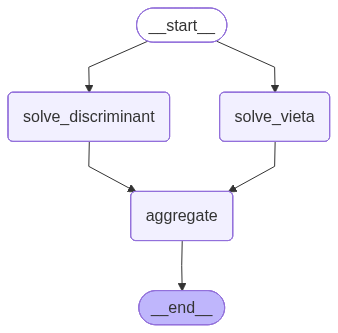

In [12]:
def solve_discriminant(state: MathState):
    llm = ChatOpenAI(
        model="gpt-5.4-mini", 
        temperature=0.0
        )    
    prompt = f"Реши квадратное уравнение через дискриминант шаг за шагом: {state['equation']}."
    res = llm.invoke(prompt)
    return {"disc_solution": res.content}

def solve_vieta(state: MathState):
    llm = ChatOpenAI(
        model="gpt-5.4-mini", 
        temperature=0.0
        )
    prompt = f"Реши квадратное уравнение через теорему Виета шаг за шагом: {state['equation']}."
    res = llm.invoke(prompt)
    return {"vieta_solution": res.content}

def aggregate(state: MathState):
    final = (
        f"Решение через дискриминант:\n{state['disc_solution']}\n\n"
        f"-------\n\n"
        f"Решение через теорему Виета:\n{state['vieta_solution']}"
    )
    return {"final_answer": final}

builder_math = StateGraph(MathState)
builder_math.add_node("solve_discriminant", solve_discriminant)
builder_math.add_node("solve_vieta", solve_vieta)
builder_math.add_node("aggregate", aggregate)

builder_math.add_edge(START, "solve_discriminant")
builder_math.add_edge(START, "solve_vieta")

builder_math.add_edge(["solve_discriminant", "solve_vieta"], "aggregate")
builder_math.add_edge("aggregate", END)

graph_math = builder_math.compile()

display(Image(graph_math.get_graph().draw_mermaid_png()))

In [22]:
eq = "x^2 - 2x + 10 = 0"
print(f"Решаем уравнение: {eq}\n")
out_math = graph_math.invoke({"equation": eq})
display(Markdown(out_math["final_answer"]))

Решаем уравнение: x^2 - 2x + 10 = 0



Решение через дискриминант:
Решим уравнение **через дискриминант**:

\[
x^2 - 2x + 10 = 0
\]

### 1) Найдём коэффициенты
Сравним с общим видом:

\[
ax^2 + bx + c = 0
\]

Здесь:

- \(a = 1\)
- \(b = -2\)
- \(c = 10\)

### 2) Вычислим дискриминант
Формула:

\[
D = b^2 - 4ac
\]

Подставим:

\[
D = (-2)^2 - 4 \cdot 1 \cdot 10 = 4 - 40 = -36
\]

### 3) Анализируем дискриминант
Так как

\[
D < 0
\]

то **действительных корней нет**.

### 4) Найдём комплексные корни
Формула корней:

\[
x = \frac{-b \pm \sqrt{D}}{2a}
\]

Подставим:

\[
x = \frac{-(-2) \pm \sqrt{-36}}{2 \cdot 1}
= \frac{2 \pm 6i}{2}
\]

\[
x = 1 \pm 3i
\]

### Ответ:
\[
\boxed{x_1 = 1 + 3i,\quad x_2 = 1 - 3i}
\]

Если хочешь, могу ещё показать, как решить это уравнение **через выделение полного квадрата**.

-------

Решение через теорему Виета:
Решим по теореме Виета.

Дано уравнение:

\[
x^2 - 2x + 10 = 0
\]

### 1. Сравним с общим видом
Общий вид квадратного уравнения:

\[
x^2 + bx + c = 0
\]

Здесь:

- \(b = -2\)
- \(c = 10\)

### 2. По теореме Виета
Если уравнение имеет корни \(x_1\) и \(x_2\), то:

\[
x_1 + x_2 = 2
\]
потому что \(-b = -(-2) = 2\),

и

\[
x_1x_2 = 10
\]

### 3. Попробуем подобрать числа
Нужно найти два числа, которые:

- в сумме дают \(2\),
- в произведении дают \(10\).

Таких **действительных чисел нет**, потому что:

- \(1\) и \(10\) дают сумму \(11\),
- \(2\) и \(5\) дают сумму \(7\),
- \(-1\) и \(-10\) дают сумму \(-11\),
- \(-2\) и \(-5\) дают сумму \(-7\).

Ни одна пара не подходит.

### 4. Вывод
По теореме Виета видно, что **действительных корней нет**.

Если проверить через дискриминант:

\[
D = (-2)^2 - 4 \cdot 1 \cdot 10 = 4 - 40 = -36
\]

Так как \(D < 0\), корней в действительных числах действительно нет.

### 5. Комплексные корни
Если нужны комплексные корни, то:

\[
x = \frac{2 \pm \sqrt{-36}}{2} = \frac{2 \pm 6i}{2} = 1 \pm 3i
\]

### Ответ:
- **В действительных числах решений нет**
- **В комплексных числах:** \(\boxed{x = 1 \pm 3i}\)



<p class="task" id="3"></p>

3\. Вам дано два фрагмента текста. В одном из говорится, почему автор любит котиков, а в другом - почему автор любит собачек. При помощи `langchain` реализуйте систему, которая должна определить животное, выделить причину любви автора и, в зависимости от результата, "ответить" на соответствующем языке (кошачьем или собачьем).

Требования к решению:
- состояние графа должна хранить входной текст, объект классификации и итоговую реплику
- модель, которая классифицирует любимое животная, должна возвращать структурирированный объект (используйте `pydantic`) с видом животного (собака / кошка) и причиной любви

```json
{
    "animal": "КОШКА",
    "reason": "..."
}
```

- граф имеет условные ребра для генерации итогового сообщения, поток вычислений определяется видом животного



Выведите на экран графовое представление итогового конвейера. Продемонстрируйте работу на данных примерах.


- [x] Проверено на семинаре

In [16]:
cats_lover_msg = "Я обожаю кошек за их независимый характер и мягкие шершащие лапки, которые всегда радуют меня своим прикосновением."
dogs_lover_msg = "Собак я люблю за их преданность и энергичность, которые делают каждую прогулку незабываемой и полной веселья."

In [15]:
class AnimalReason(BaseModel):
    animal: Literal["КОШКА", "СОБАКА"] = Field(description="Животное, упомянутое в тексте (КОШКА или СОБАКА)")
    reason: str = Field(description="Причина, почему автор любит это животное")

class PetState(TypedDict):
    text: str
    animal: str
    reason: str
    reply: str

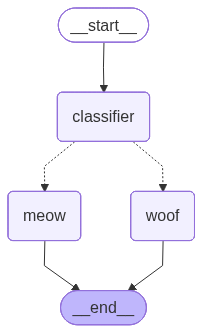

In [19]:
def classify_and_extract(state: PetState):
    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        temperature=0
        )
    structured_llm = llm.with_structured_output(AnimalReason)
    res = structured_llm.invoke(state["text"])
    return {"animal": res.animal, "reason": res.reason}

def meow_node(state: PetState):
    return {"reply": f"Мяу! Человек уважает меня за: {state['reason']}."}

def woof_node(state: PetState):
    return {"reply": f"Гав! Человек обожает меня за: {state['reason']}."}

def route_animal(state: PetState):
    if state["animal"] == "КОШКА":
        return "meow"
    return "woof"

builder_pet = StateGraph(PetState)
builder_pet.add_node("classifier", classify_and_extract)
builder_pet.add_node("meow", meow_node)
builder_pet.add_node("woof", woof_node)

builder_pet.add_edge(START, "classifier")
builder_pet.add_conditional_edges(
    "classifier", 
    route_animal, 
    {"meow": "meow", "woof": "woof"}
)
builder_pet.add_edge("meow", END)
builder_pet.add_edge("woof", END)

graph_pet = builder_pet.compile()

display(Image(graph_pet.get_graph().draw_mermaid_png()))


In [20]:
msgs = [
    cats_lover_msg,
    dogs_lover_msg
]

for msg in msgs:
    print(f"\nВходной текст: {msg}")
    out = graph_pet.invoke({"text": msg})
    print(f"Ответ: {out['reply']}")


Входной текст: Я обожаю кошек за их независимый характер и мягкие шершащие лапки, которые всегда радуют меня своим прикосновением.
Ответ: Мяу! Человек уважает меня за: за их независимый характер и мягкие шершащие лапки, которые всегда радуют прикосновением.

Входной текст: Собак я люблю за их преданность и энергичность, которые делают каждую прогулку незабываемой и полной веселья.
Ответ: Гав! Человек обожает меня за: Преданность и энергичность, которые делают каждую прогулку незабываемой и полной веселья..


<p class="task" id="4"></p>

4\. Вам дано 2 источника информации об магазине электроники:
- база данных, содержащая информацию о статусах заказов
- FAQ, содержащий ответы на самые частые вопросы

Требуется разработать систему с применением `langgraph`, которая работает следующим образом:
- классифицирует запрос (информация о статусе, технический вопрос, другое)
- если запрос информации о статусе, то при помощи соответствующего инструмента (функции) агент выполняет запрос к базе данных и выдает ответ
- если вопрос технический, то агент с применением технологии RAG для поиска по FAQ отвечает на вопрос
- если вопрос не относится к этим категориям, то агент пытается ответить самостоятельно

Продемонстрируйте примеры работы системы.



- [ ] Проверено на семинаре